# Reproducing Results from this notebook (7/9/2026)

In [1]:
import random
random_seed = 10
random.seed(random_seed)

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


# Test, Train, Val Data

In [3]:
dominant_topic_df = pd.read_csv('/content/gdrive/MyDrive/Group 3: palm oil topic classifier/Data/Labeled Data/dominant_topic_results.csv')
print(len(dominant_topic_df))
dominant_topic_df.head()

387


,Document_Num,Dominant_Topic,Topic_%_Contrib,Topic_Keywords,Text,Is_Outlier,Dom_Topics_Num,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_0_Perc,Topic_1_Perc,Topic_2_Perc,Topic_3_Perc,Topic_4_Perc,Topic_5_Perc
0,0,4,0.99,"workers, labour, union, employment, casual, da...",transferred different department purportedly p...,False,1,0,0,0,0,1,0,0.01,0.00,0.00,0.00,0.99,0.00
1,1,4,0.97,"workers, labour, union, employment, casual, da...",unjustifiably dismissed workers deceiving resi...,False,1,0,0,0,0,1,0,0.01,0.00,0.01,0.00,0.97,0.01
2,2,0,0.93,"land, communities, rights, local, allegations,...",1 owns operates plantations conflicted contest...,False,1,1,0,0,0,0,0,0.93,0.00,0.01,0.01,0.01,0.04
3,3,2,0.77,"eof, forest, mill, plantation, illegal, gar, p...",corporate social responsibility csr program co...,False,1,0,0,1,0,0,0,0.07,0.01,0.77,0.03,0.03,0.10
4,4,5,0.81,"hcv, land, area, forest, npp, new, local, rspo...",breached obligations ignoring high conservatio...,False,1,0,0,0,0,0,1,0.10,0.01,0.04,0.02,0.01,0.81


In [4]:
from sklearn.model_selection import train_test_split

# Assuming dominant_topic_df is the DataFrame you want to split
# Define the features (X) and the target (y)
# Here, we'll use the 'Text' column as the feature
X = dominant_topic_df['Text']

# And the topic probability columns and Dominant_Topic as the target (y)
# Changed to include Topic_0 through Topic_5 instead of the percentage columns
topic_columns = [col for col in dominant_topic_df.columns if col.startswith('Topic_') and len(col) == 7 and not col.endswith('_Perc')]
y = dominant_topic_df[['Document_Num'] + topic_columns]


# Perform the 80/20 split
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,  # 20% for validation
    random_state=random_seed # Use the predefined random_seed for reproducibility
    # Stratify is not directly applicable to multi-output targets like this,
    # so we will remove it.
)

print("Training set size:", len(X_train))
print("Validation set size:", len(X_val))
print("\nShape of X_train:", X_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_val:", y_val.shape)

Training set size: 309
Validation set size: 78

Shape of X_train: (309,)
Shape of X_val: (78,)
Shape of y_train: (309, 7)
Shape of y_val: (78, 7)


In [5]:
display(X_train.head())
display(X_val.head())
display(y_train.head())
display(y_val.head())

,Text
214,greenpeace final countdown allegations defores...
330,8 december 2022 ran published titled notorious...
10,infringed private property firebreak destroyed...
76,allegation expansion land approximately 150 ha...
199,ran oppuk ilrf published human cost conflict a...


,Text
197,various reports hcv clearances violations ioi ...
282,mighty earth rrr 29 indications 12 ha deforest...
267,rapid response 23 mighty earth indications 42 ...
66,summary allegations follows 1 committed discri...
331,nov 23rd 2022 gar received grievance customer ...


,Document_Num,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
214,214,0,1,0,1,0,0
330,330,0,0,0,1,0,0
10,10,1,0,0,0,0,0
76,76,1,0,0,0,0,0
199,199,0,0,1,0,0,0


,Document_Num,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
197,197,0,0,0,0,0,1
282,282,0,1,0,0,0,0
267,267,0,1,0,0,0,0
66,66,0,0,0,0,1,0
331,331,0,0,1,0,0,0


In [6]:
test_df = pd.read_csv('/content/gdrive/MyDrive/Group 3: palm oil topic classifier/Text Classification Models/classified_grievances_multilabel.csv')

test_df = test_df[['pk', 'summary', 'Topic_0', 'Topic_1', 'Topic_2', 'Topic_3', 'Topic_4', "Topic_5"]]

In [7]:
len(test_df)

170

In [8]:
# Display the head of the updated DataFrame to confirm
display(test_df.head())

,pk,summary,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,431,"In July 2020, Cargill received a grievance aga...",0,1,0,1,1,0
1,432,A grievance was filed against Agropalma regard...,1,0,0,0,1,0
2,433,This grievance was filed by Friends of the Ear...,1,0,0,0,0,0
3,434,A grievance was filed against Brasil Bio Fuels...,0,0,0,1,1,0
4,435,A grievance was filed by Link-Ar Borneo agains...,1,0,0,0,0,0


# Twitter

In [9]:
# Imports

!pip install transformers
!pip install -U datasets

from collections import defaultdict, Counter
import json
import numpy as np
import torch
import pandas as pd

from matplotlib import pyplot as plt

from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoModel
from datasets import load_dataset, DatasetDict
from torch.utils.data import DataLoader
from transformers import DistilBertConfig, DistilBertTokenizer, DistilBertForSequenceClassification, DistilBertModel
from transformers import get_linear_schedule_with_warmup
from tqdm.notebook import tqdm
from torch.optim import AdamW
from transformers import set_seed
from sklearn.metrics import accuracy_score, f1_score
from datasets import load_dataset, DatasetDict, Dataset
from torch.utils.data import DataLoader

# Tokenizer

In [10]:
tokenizer_length = 512

In [11]:
# Tokenizing

# Train and Validation
tokenizer = AutoTokenizer.from_pretrained("Twitter/twhin-bert-base")

# Convert pandas Series to datasets.Dataset for easier mapping
# Exclude 'Document_Num' from labels for training and validation sets
topic_columns = [col for col in dominant_topic_df.columns if col.startswith('Topic_') and len(col) == 7 and not col.endswith('_Perc')]
train_dataset = Dataset.from_pandas(pd.DataFrame({'Text': X_train, 'labels': y_train[topic_columns].values.tolist()}))
val_dataset = Dataset.from_pandas(pd.DataFrame({'Text': X_val, 'labels': y_val[topic_columns].values.tolist()}))

# Apply tokenization using map
tokenized_train = train_dataset.map(
    lambda example: tokenizer(example['Text'],
                             padding="max_length",
                             truncation=True,
                             max_length=tokenizer_length),
    batched=True
)

# Remove the original text column (we don't need it after tokenization)
tokenized_train = tokenized_train.remove_columns(['Text'])

# Set format to torch tensors
tokenized_train.set_format("torch")

# Check the results
print("Tokenized training dataset features:", tokenized_train.column_names)
print("Training dataset size:", len(tokenized_train))
print("\nSample training data shapes:")
print(f"- input_ids: {tokenized_train[0]['input_ids'].shape}")
print(f"- attention_mask: {tokenized_train[0]['attention_mask'].shape}")
print(f"- labels shape: {tokenized_train[0]['labels'].shape}")
print(f"- labels type: {type(tokenized_train[0]['labels'])}")


tokenized_validation = val_dataset.map(
    lambda example: tokenizer(example['Text'],
                             padding="max_length",
                             truncation=True,
                             max_length=tokenizer_length,),
    batched=True
)

tokenized_validation = tokenized_validation.remove_columns(['Text'])

tokenized_validation.set_format("torch")

print("\nTokenized validation dataset size:", len(tokenized_validation))
print("Sample validation data shapes:")
print(f"- input_ids: {tokenized_validation[0]['input_ids'].shape}")
print(f"- attention_mask: {tokenized_validation[0]['attention_mask'].shape}")
print(f"- labels shape: {tokenized_validation[0]['labels'].shape}")
print(f"- labels type: {type(tokenized_validation[0]['labels'])}")


# Test
# Separate features and labels for the test set
# Use 'summary' as the text feature and the multi-hot encoded topics as the labels
X_test = test_df['summary']
# Convert the multi-hot encoded topic labels to a list of lists
y_test_labels_list = test_df[topic_columns].values.tolist()
test_pk = test_df['pk'] # Keep 'pk' separately

test_dataset = Dataset.from_pandas(pd.DataFrame({'Text': X_test, 'labels': y_test_labels_list, 'pk': test_pk}))

tokenized_test = test_dataset.map(
     lambda example: tokenizer(example['Text'],
                              padding="max_length",
                              truncation=True,
                              max_length=tokenizer_length),
    batched=True
)

tokenized_test = tokenized_test.remove_columns(['Text'])
tokenized_test.set_format("torch")

print("\nTokenized test dataset size:", len(tokenized_test))
print("Sample test data shapes:")
print(f"- input_ids: {tokenized_test[0]['input_ids'].shape}")
print(f"- attention_mask: {tokenized_test[0]['attention_mask'].shape}")
# The labels for the test set are now the multi-hot encoded labels
print(f"- labels: {tokenized_test[0]['labels']}")
print(f"- labels type: {type(tokenized_test[0]['labels'])}")
print(f"- pk: {tokenized_test[0]['pk']}")
print(f"- pk type: {type(tokenized_test[0]['pk'])}")

config.json:   0%|          | 0.00/632 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/372 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Map:   0%|          | 0/309 [00:00<?, ? examples/s]

Tokenized training dataset features: ['labels', '__index_level_0__', 'input_ids', 'attention_mask']
Training dataset size: 309

Sample training data shapes:
- input_ids: torch.Size([512])
- attention_mask: torch.Size([512])
- labels shape: torch.Size([6])
- labels type: <class 'torch.Tensor'>


Map:   0%|          | 0/78 [00:00<?, ? examples/s]


Tokenized validation dataset size: 78
Sample validation data shapes:
- input_ids: torch.Size([512])
- attention_mask: torch.Size([512])
- labels shape: torch.Size([6])
- labels type: <class 'torch.Tensor'>


Map:   0%|          | 0/170 [00:00<?, ? examples/s]


Tokenized test dataset size: 170
Sample test data shapes:
- input_ids: torch.Size([512])
- attention_mask: torch.Size([512])
- labels: tensor([0, 1, 0, 1, 1, 0])
- labels type: <class 'torch.Tensor'>
- pk: 431
- pk type: <class 'torch.Tensor'>


# Batchify Data

In [12]:
batch_size = 4 # Base is 4

In [13]:
train_dataset = tokenized_train.shuffle(seed=1111).select(range(309))
train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
eval_dataloader = DataLoader(tokenized_validation, batch_size=batch_size)

# Training and Validation

In [22]:
model_path = '/content/gdrive/MyDrive/Group 3: palm oil topic classifier/Text Classification Models/Twitter_Saved_Models/'
model_name = "20260709_Twitter"

In [15]:
set_seed(42)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForSequenceClassification.from_pretrained(
          "Twitter/twhin-bert-base",
          num_labels=6,
          hidden_dropout_prob=0.4,
          attention_probs_dropout_prob=0.4
      ).to(device)

num_epochs = 50
num_training_steps = len(train_dataloader) * num_epochs

# optimizer = AdamW(model.parameters(), lr=3e-5, weight_decay=0.01)
optimizer = AdamW(model.parameters(), lr=1.52e-05, weight_decay=0.18,)  # Halved Learning Rate

# lr_scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)
lr_scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.113 * num_training_steps),  # 10% warmup
    num_training_steps=num_training_steps
)

# Use BCEWithLogitsLoss for multi-label classification
loss_fct = torch.nn.BCEWithLogitsLoss()

# For Graph
x_epochs = []
y_train = []
y_val = []

best_val_loss = float("inf")

early_stopping = True
early_count = 0 # +1 every time validation loss doesnt improve
early_limit = 5

progress_bar = tqdm(range(num_training_steps))
for epoch in range(num_epochs):
    x_epochs.append(epoch)

    # training
    model.train()
    training_losses = []
    for batch_i, batch in enumerate(train_dataloader):

        optimizer.zero_grad()

        # copy input to device
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        # Convert labels to float and move to device
        labels = batch['labels'].to(device).float()


        # output = model(**batch)
        # Pass input_ids and attention_mask to the model
        output = model(input_ids, attention_mask=attention_mask)
        # Calculate loss using BCEWithLogitsLoss
        training_loss = loss_fct(output.logits, labels)

        training_losses.append(training_loss.item())

        #backprop and update params by taking an optimization step
        training_loss.backward()
        optimizer.step()
        lr_scheduler.step()
        progress_bar.update(1)
    print(f"\nEpoch {epoch}:")
    print("Mean Training Loss", np.mean(training_losses))
    y_train.append(np.mean(training_losses))

    # validation
    val_loss = 0
    model.eval() #important to call because we dont want to collect gradients
    for batch_i, batch in enumerate(eval_dataloader):
        with torch.no_grad():
            # copy input to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            # Convert labels to float and move to device
            labels = batch['labels'].to(device).float()
            # output = model(**batch)
            # Pass input_ids and attention_mask to the model
            output = model(input_ids, attention_mask=attention_mask)

        # Calculate loss using BCEWithLogitsLoss
        val_loss += loss_fct(output.logits, labels)


    avg_val_loss = val_loss / len(eval_dataloader)
    print(f"Validation loss: {avg_val_loss}")
    y_val.append(avg_val_loss.cpu())

    if avg_val_loss < best_val_loss:
        print("Saving checkpoint!")
        early_count = 0 # Reset counter
        best_val_loss = avg_val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            # 'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            },
            f"{model_path}{model_name}_best_model.pt"
        )
    elif early_stopping:
        early_count += 1

        if early_count == early_limit:
            print(f"Validation loss has not improved for {early_limit} iterations; Early Stopping.")
            break

    print()

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: Twitter/twhin-bert-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.distance_embedding.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias                                 | UNEXPECTED | 
cls.predictions.bias                                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                           | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias                             | UNEXPECTED | 
cls.predictions.transform.dense.weight                               | UNEXPECTED | 
classifier.weight                                                    | MISSING    | 
bert.pooler.dense.bias                                               | MISSING    | 
bert.pooler.dense.weight                                       

  0%|          | 0/3900 [00:00<?, ?it/s]


Epoch 0:
Mean Training Loss 0.6736518274515103
Validation loss: 0.5938956141471863
Saving checkpoint!


Epoch 1:
Mean Training Loss 0.5653145970442356
Validation loss: 0.5000317692756653
Saving checkpoint!


Epoch 2:
Mean Training Loss 0.5116280985948367
Validation loss: 0.49009522795677185
Saving checkpoint!


Epoch 3:
Mean Training Loss 0.5017446772410319
Validation loss: 0.491594523191452


Epoch 4:
Mean Training Loss 0.495191453741147
Validation loss: 0.48896321654319763
Saving checkpoint!


Epoch 5:
Mean Training Loss 0.4904142839786334
Validation loss: 0.4858754575252533
Saving checkpoint!


Epoch 6:
Mean Training Loss 0.485570578620984
Validation loss: 0.4818536937236786
Saving checkpoint!


Epoch 7:
Mean Training Loss 0.4911085871549753
Validation loss: 0.47718116641044617
Saving checkpoint!


Epoch 8:
Mean Training Loss 0.4887060977709599
Validation loss: 0.4674905240535736
Saving checkpoint!


Epoch 9:
Mean Training Loss 0.48457496135662764
Validation loss: 0.45562544465065


Text(0.5, 0, 'Epochs')

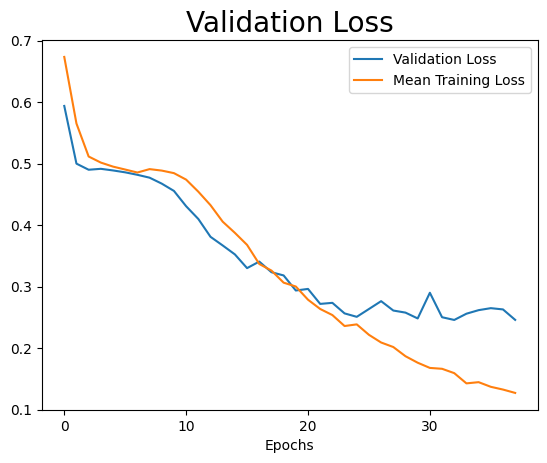

In [16]:
plt.plot(x_epochs, y_val, label="Validation Loss")
plt.plot(x_epochs, y_train, label="Mean Training Loss")
plt.legend()
plt.style.use('fivethirtyeight')
plt.title("Validation Loss")
plt.xlabel("Epochs")

# Predict on Test

In [24]:
model = AutoModelForSequenceClassification.from_pretrained(
          "Twitter/twhin-bert-base",
          num_labels=6,
          hidden_dropout_prob=0.4,
          attention_probs_dropout_prob=0.4
      ).to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the best model
best_model_path = f"{model_path}{model_name} best_model.pt"
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval() # Set the model to evaluation mode


# Create a DataLoader for the test set
test_dataloader = DataLoader(tokenized_test, batch_size=batch_size)

predictions = []
pk_values = [] # To store pk values

with torch.no_grad():
    for batch in tqdm(test_dataloader, desc="Predicting on test data"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        # Move pk to CPU and convert to numpy
        pk = batch['pk'].cpu().numpy()
        pk_values.extend(pk)


        outputs = model(input_ids, attention_mask=attention_mask)
        logits = outputs.logits

        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        predictions.extend(probs.cpu().numpy())

# Convert predictions to a DataFrame
prediction_df = pd.DataFrame(predictions, columns=[f'Topic_{i}_Prob' for i in range(6)])

# Add the original text and pk back to the prediction DataFrame
# We need to get the original text and pk from the test_df or tokenized_test dataset
# Since tokenized_test has 'pk' and we can get 'summary' from test_df using 'pk'
# Let's create a mapping from pk to summary from the original test_df
pk_to_text = test_df.set_index('pk')['summary'].to_dict()

# Add 'pk' and 'summary' to the prediction_df
prediction_df['pk'] = pk_values # Use the collected numpy array of pk values
prediction_df['summary'] = prediction_df['pk'].map(pk_to_text)

# Rearrange columns to have pk and summary first
cols = ['pk', 'summary'] + [col for col in prediction_df.columns if col not in ['pk', 'summary']]
prediction_df = prediction_df[cols]

display(prediction_df.head())

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: Twitter/twhin-bert-base
Key                                                                  | Status     | 
---------------------------------------------------------------------+------------+-
bert.encoder.layer.{0...11}.attention.self.distance_embedding.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias                                 | UNEXPECTED | 
cls.predictions.bias                                                 | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight                           | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias                             | UNEXPECTED | 
cls.predictions.transform.dense.weight                               | UNEXPECTED | 
classifier.weight                                                    | MISSING    | 
bert.pooler.dense.bias                                               | MISSING    | 
bert.pooler.dense.weight                                       

Predicting on test data:   0%|          | 0/43 [00:00<?, ?it/s]

,pk,summary,Topic_0_Prob,Topic_1_Prob,Topic_2_Prob,Topic_3_Prob,Topic_4_Prob,Topic_5_Prob
0,431,"In July 2020, Cargill received a grievance aga...",0.092676,0.022513,0.151142,0.078589,0.006226,0.842101
1,432,A grievance was filed against Agropalma regard...,0.713014,0.021971,0.045592,0.022580,0.005061,0.711983
2,433,This grievance was filed by Friends of the Ear...,0.892248,0.017577,0.027857,0.018325,0.010509,0.466411
3,434,A grievance was filed against Brasil Bio Fuels...,0.151347,0.009444,0.186000,0.052205,0.007228,0.804846
4,435,A grievance was filed by Link-Ar Borneo agains...,0.168859,0.021067,0.112860,0.057676,0.005353,0.851331


In [25]:
test_df.head()

,pk,summary,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,431,"In July 2020, Cargill received a grievance aga...",0,1,0,1,1,0
1,432,A grievance was filed against Agropalma regard...,1,0,0,0,1,0
2,433,This grievance was filed by Friends of the Ear...,1,0,0,0,0,0
3,434,A grievance was filed against Brasil Bio Fuels...,0,0,0,1,1,0
4,435,A grievance was filed by Link-Ar Borneo agains...,1,0,0,0,0,0


In [ ]:
# create binary_prediction_df
# compare to test_df
# calculate f1, accuracy, etc
# calculations should be independent of each other

In [26]:
from sklearn.metrics import accuracy_score, f1_score

# Define the threshold for converting probabilities to binary labels
evaluation_threshold = 0.1

# Get the predicted probabilities for the topic columns from prediction_df
topic_prob_columns = [col for col in prediction_df.columns if col.startswith('Topic_') and col.endswith('_Prob')]
predicted_probs = prediction_df[topic_prob_columns].values

# Convert probabilities to binary predictions using the threshold
binary_predictions = (predicted_probs >= evaluation_threshold).astype(int)

# Get the true multi-hot encoded labels from test_df
# Ensure alignment with prediction_df based on 'pk'
# Assuming test_df contains 'pk' and 'Topic_0' through 'Topic_5'
true_labels_for_eval = pd.merge(prediction_df[['pk']], test_df[['pk'] + [f'Topic_{i}' for i in range(6)]], on='pk', how='left')

# Extract the true labels in the correct order
true_labels_values = true_labels_for_eval[[f'Topic_{i}' for i in range(6)]].values

# Create a DataFrame for binary predictions (optional, but requested)
binary_prediction_df = pd.DataFrame(binary_predictions, columns=[f'Topic_{i}' for i in range(6)])
# Add pk for potential merging or inspection
binary_prediction_df['pk'] = prediction_df['pk']
# Rearrange columns
cols = ['pk'] + [col for col in binary_prediction_df.columns if col != 'pk']
binary_prediction_df = binary_prediction_df[cols]


# Display the probability predictions DataFrame
print("Probability Predictions (first 5 rows):")
display(prediction_df.head())

# Display the binary predictions DataFrame
print("\nBinary Predictions (first 5 rows):")
display(binary_prediction_df.head())


# Calculate Overall Accuracy, Micro F1 Score, and Macro F1 Score
overall_accuracy = accuracy_score(true_labels_values, binary_predictions)
overall_f1_micro = f1_score(true_labels_values, binary_predictions, average='micro')
overall_f1_macro = f1_score(true_labels_values, binary_predictions, average='macro')


print(f"\nOverall Evaluation Results (Threshold = {evaluation_threshold}):")
print(f"Accuracy: {overall_accuracy:.4f}")
print(f"Micro F1 Score: {overall_f1_micro:.4f}")
print(f"Macro F1 Score: {overall_f1_macro:.4f}")


# Calculate Accuracy and F1 Score for each label
print("\nEvaluation Results per Label (Threshold =", evaluation_threshold, "):")
for i in range(6):
    topic_col_name = f'Topic_{i}'
    # Accuracy for the current label
    accuracy = accuracy_score(true_labels_values[:, i], binary_predictions[:, i])
    # F1 score for the current label
    f1 = f1_score(true_labels_values[:, i], binary_predictions[:, i])

    print(f"{topic_col_name}: Accuracy = {accuracy:.4f}, F1 Score = {f1:.4f}")

# Note: You can easily change the 'evaluation_threshold' variable above and re-run this cell
# to see the impact on accuracy and F1 score for each label.

Probability Predictions (first 5 rows):


,pk,summary,Topic_0_Prob,Topic_1_Prob,Topic_2_Prob,Topic_3_Prob,Topic_4_Prob,Topic_5_Prob
0,431,"In July 2020, Cargill received a grievance aga...",0.092676,0.022513,0.151142,0.078589,0.006226,0.842101
1,432,A grievance was filed against Agropalma regard...,0.713014,0.021971,0.045592,0.022580,0.005061,0.711983
2,433,This grievance was filed by Friends of the Ear...,0.892248,0.017577,0.027857,0.018325,0.010509,0.466411
3,434,A grievance was filed against Brasil Bio Fuels...,0.151347,0.009444,0.186000,0.052205,0.007228,0.804846
4,435,A grievance was filed by Link-Ar Borneo agains...,0.168859,0.021067,0.112860,0.057676,0.005353,0.851331



Binary Predictions (first 5 rows):


,pk,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,431,0,0,1,0,0,1
1,432,1,0,0,0,0,1
2,433,1,0,0,0,0,1
3,434,1,0,1,0,0,1
4,435,1,0,1,0,0,1



Overall Evaluation Results (Threshold = 0.1):
Accuracy: 0.0294
Micro F1 Score: 0.5243
Macro F1 Score: 0.5108

Evaluation Results per Label (Threshold = 0.1 ):
Topic_0: Accuracy = 0.7529, F1 Score = 0.5532
Topic_1: Accuracy = 0.6588, F1 Score = 0.6282
Topic_2: Accuracy = 0.5824, F1 Score = 0.5419
Topic_3: Accuracy = 0.6706, F1 Score = 0.6923
Topic_4: Accuracy = 0.8882, F1 Score = 0.3871
Topic_5: Accuracy = 0.2059, F1 Score = 0.2623


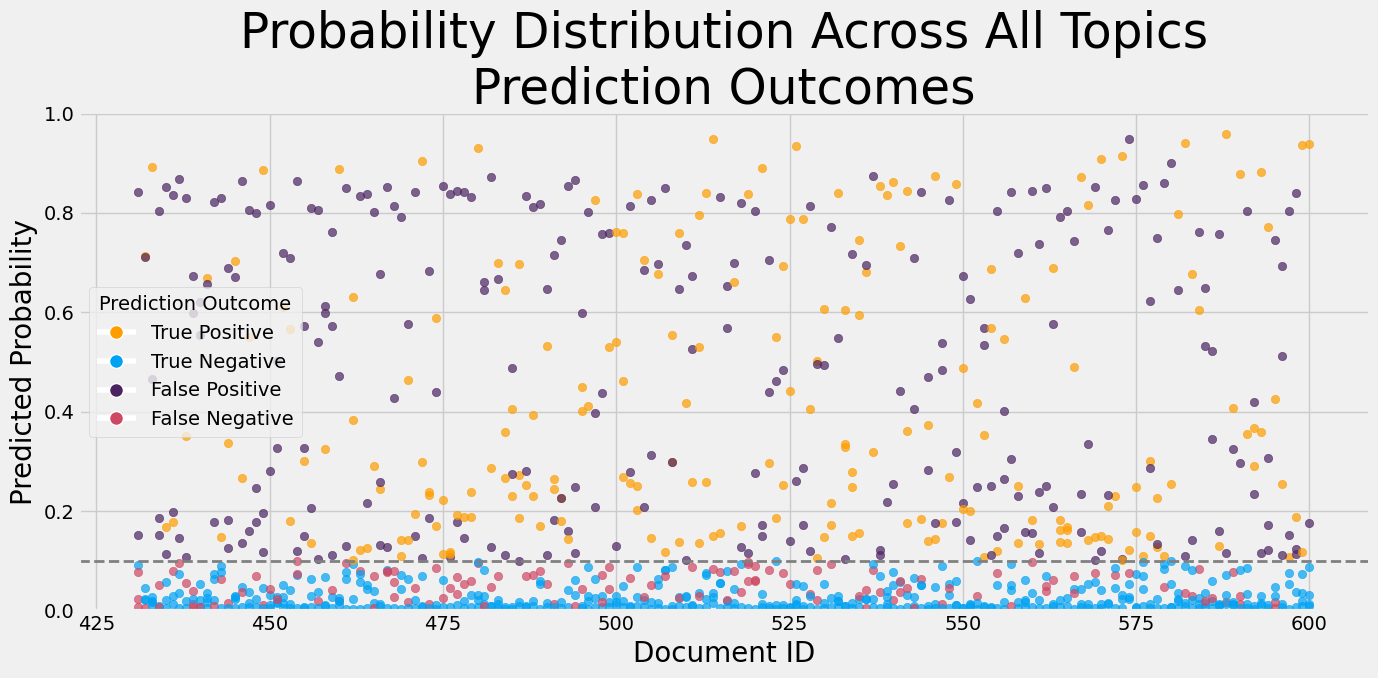

In [27]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

# Set threshold
eval_threshold_vis = evaluation_threshold

# Get all topic numbers by extracting from prediction_df columns
topic_prob_cols = [col for col in prediction_df.columns if col.startswith("Topic_") and col.endswith("_Prob")]

# Collect all rows across all topics
combined_points = []

for prob_col in topic_prob_cols:
    topic_num = prob_col.split("_")[1]
    true_col = f"Topic_{topic_num}"

    true_labels = true_labels_for_eval[true_col].values
    predicted_probs = prediction_df[prob_col].values
    binary_preds = (predicted_probs >= eval_threshold_vis).astype(int)
    pk_values = prediction_df['pk'].values

    a = "#FF9D00"
    b = "#00A2F3"
    c = "#4B2362"
    d = "#CE4763"


    for pk, prob, true, pred in zip(pk_values, predicted_probs, true_labels, binary_preds):
        if true == 1 and pred == 1:
            outcome = "TP"
            color = a
        elif true == 0 and pred == 0:
            outcome = "TN"
            color = b
        elif true == 0 and pred == 1:
            outcome = "FP"
            color = c
        elif true == 1 and pred == 0:
            outcome = "FN"
            color = d
        else:
            continue  # shouldn't happen
        combined_points.append((pk, prob, color, outcome))

# Create scatterplot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot each point with correct color
for pk, prob, color, _ in combined_points:
    ax.scatter(pk, prob, color=color, alpha=0.7)

# Add threshold line with label
ax.axhline(eval_threshold_vis, color='gray', linestyle='dashed', linewidth=2, label='Threshold')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='True Positive', markerfacecolor=a, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='True Negative', markerfacecolor=b, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='False Positive', markerfacecolor=c, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='False Negative', markerfacecolor=d, markersize=10),
    Line2D([0], [0], color='gray', linestyle='dashed', linewidth=2, label='Threshold'),
]

ax.legend(handles=legend_elements, title='Prediction Outcome')


# Customize
ax.set_title(f'Probability Distribution Across All Topics\nPrediction Outcomes', fontsize=35)
ax.set_xlabel('Document ID', fontsize=20)
ax.set_ylabel('Predicted Probability', fontsize=20)
ax.set_ylim(0, 1)
ax.spines[['top', 'right']].set_visible(False)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='True Positive', markerfacecolor=a, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='True Negative', markerfacecolor=b, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='False Positive', markerfacecolor=c, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='False Negative', markerfacecolor=d, markersize=10),
]
ax.legend(handles=legend_elements, title='Prediction Outcome')

plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()
